# **TERABYTES**

**1. Sonya Audina Akbar (24083010013)**

**2. Fanny Widya Cahyani (24083010045)**

**3. Siti Naia Hesti Rachmawati (24083010047)**

**4. M. Wildan Sultansyah (240830100**

# **Deskripsi Data**

**Metode Pengambilan Data**

> Data diperoleh melalui teknik Web Scraping secara mandiri pada platform Lazada Indonesia. Proses pengambilan data berfokus pada toko resmi (official store) Watsons dan Dan+Dan untuk memastikan validitas sumber.

**Spesifikasi Data**

**1. Toko Watsons**

> Sumber: Lazada Indonesia

> Waktu Pengambilan: 2 April 2026

> Jumlah Data: 2000 baris dan 14 kolom

> Atribut Data: toko, nama_produk, harga, harga_original, diskon, rating, jumlah_review, jumlah_terjual, nama_toko_lazada, lokasi, brand, url_produk, url_gambar, tanggal_scraping


**2. Toko Dan+Dan**

> Sumber: Lazada Indonesia

> Waktu Pengambilan: 7 April 2026

> Jumlah Data: 1.666 baris

> Atribut Data: toko, nama_produk, harga, harga_origin, diskon, rating, jumlah_review, jumlah_terjual, lokasi, kategori, brand, url_produk, url_gambar, tanggal_scraping


**3. Dataset FInal yang Sudah Di Merge**

> Sumber: Lazada Indonesia

> Jumlah Data: 3.666 baris

> Atribut Data: toko, nama_produk, harga, harga_original, diskon, rating, jumlah_review, jumlah_terjual, lokasi, url_produk, url_gambar, tanggal_scraping

# **Load Data**

In [ ]:
# load data
import pandas as pd
import re
import matplotlib.pyplot as plt

url_watsons = "https://raw.githubusercontent.com/naiarch/UTS-Big-Data-Web-Scraping-Lazada/main/lazada_watsons.csv"
url_dandan = "https://raw.githubusercontent.com/naiarch/UTS-Big-Data-Web-Scraping-Lazada/main/lazada_dandan.csv"

df_watsons = pd.read_csv(url_watsons, sep=";", encoding="latin-1", engine="python")
df_dandan = pd.read_csv(url_dandan, sep=",", encoding="latin-1", engine="python")

# **Toko Watsons**

In [ ]:
df_watsons.head()

,ï»¿toko,nama_produk,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual,nama_toko_lazada,lokasi,brand,url_produk,url_gambar,tanggal_scraping
0,Watsons,Giv Beauty Liquid Bodywash Purple Passion Flow...,24000,445000.0,46% Off,"4,926920454",39587,78900,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i7990080...,https://id-live-01.slatic.net/p/c624ec05195dbf...,2026-04-02 04:20:45
1,Watsons,K Natural Body Wash Sparkling Magnolia Pouch 4...,13000,245000.0,47% Off,"4,920538583",39214,107800,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i7017440...,https://id-live-01.slatic.net/p/bd647e26e550ee...,2026-04-02 04:20:45
2,Watsons,Zinc Shampoo Refreshing Cool Green Tea Pump 680ml,39900,729000.0,45% Off,"4,947539267",19100,64900,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i7554280...,https://id-live-01.slatic.net/p/7120da9362ae0a...,2026-04-02 04:20:45
3,Watsons,Watsons Rose Scented Cream Bath Pouch 800ml,21000,349000.0,40% Off,"4,909734513",565,1500,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i8611604...,https://id-live-01.slatic.net/p/9dc396dd50c8d6...,2026-04-02 04:20:45
4,Watsons,Giv White Mulberry & Collagen Liquid Bath Soap...,24000,445000.0,46% Off,"4,929464286",16800,38200,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i7990086...,https://id-live-01.slatic.net/p/342db444b90ab9...,2026-04-02 04:20:45


In [ ]:
df_watsons.tail()

,ï»¿toko,nama_produk,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual,nama_toko_lazada,lokasi,brand,url_produk,url_gambar,tanggal_scraping
1995,Watsons,WHITE GARDEN Pink Rose Shower Cream Refill 900ml,68900,862000.0,20% Off,5,7,19,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i5194884...,https://id-live-01.slatic.net/p/2cdbece4b90882...,2026-04-02 04:23:11
1996,Watsons,Wardah Eye & Lip Makeup Remover 100ml,46000,NaN,NaN,5,3,9,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i8813134...,https://id-live-01.slatic.net/p/f2169fd3bc8662...,2026-04-02 04:23:11
1997,Watsons,Jacquelle Beaute Pop Balm - Quby Edition Watta...,63120,789000.0,20% Off,NaN,0,0,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i1882840...,https://id-live-01.slatic.net/p/31da8693dbb5f7...,2026-04-02 04:23:11
1998,Watsons,Qvs 10-1398 Curl Lash Curler,139900,NaN,NaN,NaN,0,0,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i6863564...,https://id-live-01.slatic.net/p/313db1ee4af511...,2026-04-02 04:23:11
1999,Watsons,Timephoria Eternal Lip Matte 02 Hocus,79200,990000.0,20% Off,5,1,13,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i8389570...,https://id-live-01.slatic.net/p/4adefe4dca3e20...,2026-04-02 04:23:11


In [ ]:
df_watsons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ï»¿toko           2000 non-null   object 
 1   nama_produk       2000 non-null   object 
 2   harga             2000 non-null   int64  
 3   harga_original    1358 non-null   float64
 4   diskon            1358 non-null   object 
 5   rating            1677 non-null   object 
 6   jumlah_review     2000 non-null   int64  
 7   jumlah_terjual    2000 non-null   int64  
 8   nama_toko_lazada  2000 non-null   object 
 9   lokasi            2000 non-null   object 
 10  brand             2000 non-null   object 
 11  url_produk        2000 non-null   object 
 12  url_gambar        2000 non-null   object 
 13  tanggal_scraping  2000 non-null   object 
dtypes: float64(1), int64(3), object(10)
memory usage: 218.9+ KB


In [ ]:
# @title rename kolom toko
df_watsons.rename(columns={'ï»¿toko': 'toko'}, inplace=True)
df_watsons.head()

,toko,nama_produk,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual,nama_toko_lazada,lokasi,brand,url_produk,url_gambar,tanggal_scraping
0,Watsons,Giv Beauty Liquid Bodywash Purple Passion Flow...,24000,445000.0,46% Off,"4,926920454",39587,78900,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i7990080...,https://id-live-01.slatic.net/p/c624ec05195dbf...,2026-04-02 04:20:45
1,Watsons,K Natural Body Wash Sparkling Magnolia Pouch 4...,13000,245000.0,47% Off,"4,920538583",39214,107800,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i7017440...,https://id-live-01.slatic.net/p/bd647e26e550ee...,2026-04-02 04:20:45
2,Watsons,Zinc Shampoo Refreshing Cool Green Tea Pump 680ml,39900,729000.0,45% Off,"4,947539267",19100,64900,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i7554280...,https://id-live-01.slatic.net/p/7120da9362ae0a...,2026-04-02 04:20:45
3,Watsons,Watsons Rose Scented Cream Bath Pouch 800ml,21000,349000.0,40% Off,"4,909734513",565,1500,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i8611604...,https://id-live-01.slatic.net/p/9dc396dd50c8d6...,2026-04-02 04:20:45
4,Watsons,Giv White Mulberry & Collagen Liquid Bath Soap...,24000,445000.0,46% Off,"4,929464286",16800,38200,watsons,Kab. Tangerang,Watsons,https://www.lazada.co.id/products/pdp-i7990086...,https://id-live-01.slatic.net/p/342db444b90ab9...,2026-04-02 04:20:45


In [ ]:
# @title drop kolom brand
df_watsons.drop(columns=['brand'], inplace=True)
df_watsons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              2000 non-null   object 
 1   nama_produk       2000 non-null   object 
 2   harga             2000 non-null   int64  
 3   harga_original    1358 non-null   float64
 4   diskon            1358 non-null   object 
 5   rating            1677 non-null   object 
 6   jumlah_review     2000 non-null   int64  
 7   jumlah_terjual    2000 non-null   int64  
 8   nama_toko_lazada  2000 non-null   object 
 9   lokasi            2000 non-null   object 
 10  url_produk        2000 non-null   object 
 11  url_gambar        2000 non-null   object 
 12  tanggal_scraping  2000 non-null   object 
dtypes: float64(1), int64(3), object(9)
memory usage: 203.3+ KB


In [ ]:
# @title cleaning kolom diskon
df_watsons['diskon'] = df_watsons['diskon'].str.extract(r'(\d+)')
df_watsons['diskon'] = pd.to_numeric(df_watsons['diskon'], errors='coerce') / 100

df_watsons.head()

,toko,nama_produk,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual,nama_toko_lazada,lokasi,url_produk,url_gambar,tanggal_scraping
0,Watsons,Giv Beauty Liquid Bodywash Purple Passion Flow...,24000,445000.0,0.46,"4,926920454",39587,78900,watsons,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7990080...,https://id-live-01.slatic.net/p/c624ec05195dbf...,2026-04-02 04:20:45
1,Watsons,K Natural Body Wash Sparkling Magnolia Pouch 4...,13000,245000.0,0.47,"4,920538583",39214,107800,watsons,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7017440...,https://id-live-01.slatic.net/p/bd647e26e550ee...,2026-04-02 04:20:45
2,Watsons,Zinc Shampoo Refreshing Cool Green Tea Pump 680ml,39900,729000.0,0.45,"4,947539267",19100,64900,watsons,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7554280...,https://id-live-01.slatic.net/p/7120da9362ae0a...,2026-04-02 04:20:45
3,Watsons,Watsons Rose Scented Cream Bath Pouch 800ml,21000,349000.0,0.40,"4,909734513",565,1500,watsons,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i8611604...,https://id-live-01.slatic.net/p/9dc396dd50c8d6...,2026-04-02 04:20:45
4,Watsons,Giv White Mulberry & Collagen Liquid Bath Soap...,24000,445000.0,0.46,"4,929464286",16800,38200,watsons,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7990086...,https://id-live-01.slatic.net/p/342db444b90ab9...,2026-04-02 04:20:45


In [ ]:
df_watsons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              2000 non-null   object 
 1   nama_produk       2000 non-null   object 
 2   harga             2000 non-null   int64  
 3   harga_original    1358 non-null   float64
 4   diskon            1358 non-null   float64
 5   rating            1677 non-null   object 
 6   jumlah_review     2000 non-null   int64  
 7   jumlah_terjual    2000 non-null   int64  
 8   nama_toko_lazada  2000 non-null   object 
 9   lokasi            2000 non-null   object 
 10  url_produk        2000 non-null   object 
 11  url_gambar        2000 non-null   object 
 12  tanggal_scraping  2000 non-null   object 
dtypes: float64(2), int64(3), object(8)
memory usage: 203.3+ KB


In [ ]:
# @title cleaning kolom rating

df_watsons['rating'] = df_watsons['rating'].str.replace(',', '.', regex=False)
df_watsons['rating'] = pd.to_numeric(df_watsons['rating'], errors='coerce')

# membulatkan 1 angka belakang
df_watsons['rating'] = df_watsons['rating'].round(1)

df_watsons.head()

,toko,nama_produk,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual,nama_toko_lazada,lokasi,url_produk,url_gambar,tanggal_scraping
0,Watsons,Giv Beauty Liquid Bodywash Purple Passion Flow...,24000,445000.0,0.46,4.9,39587,78900,watsons,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7990080...,https://id-live-01.slatic.net/p/c624ec05195dbf...,2026-04-02 04:20:45
1,Watsons,K Natural Body Wash Sparkling Magnolia Pouch 4...,13000,245000.0,0.47,4.9,39214,107800,watsons,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7017440...,https://id-live-01.slatic.net/p/bd647e26e550ee...,2026-04-02 04:20:45
2,Watsons,Zinc Shampoo Refreshing Cool Green Tea Pump 680ml,39900,729000.0,0.45,4.9,19100,64900,watsons,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7554280...,https://id-live-01.slatic.net/p/7120da9362ae0a...,2026-04-02 04:20:45
3,Watsons,Watsons Rose Scented Cream Bath Pouch 800ml,21000,349000.0,0.40,4.9,565,1500,watsons,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i8611604...,https://id-live-01.slatic.net/p/9dc396dd50c8d6...,2026-04-02 04:20:45
4,Watsons,Giv White Mulberry & Collagen Liquid Bath Soap...,24000,445000.0,0.46,4.9,16800,38200,watsons,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7990086...,https://id-live-01.slatic.net/p/342db444b90ab9...,2026-04-02 04:20:45


In [ ]:
df_watsons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              2000 non-null   object 
 1   nama_produk       2000 non-null   object 
 2   harga             2000 non-null   int64  
 3   harga_original    1358 non-null   float64
 4   diskon            1358 non-null   float64
 5   rating            1677 non-null   float64
 6   jumlah_review     2000 non-null   int64  
 7   jumlah_terjual    2000 non-null   int64  
 8   nama_toko_lazada  2000 non-null   object 
 9   lokasi            2000 non-null   object 
 10  url_produk        2000 non-null   object 
 11  url_gambar        2000 non-null   object 
 12  tanggal_scraping  2000 non-null   object 
dtypes: float64(3), int64(3), object(7)
memory usage: 203.3+ KB


In [ ]:
# @title mengubah tipe data kolom harga_original
df_watsons['harga_original'] = df_watsons['harga_original'].astype('Int64')
df_watsons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              2000 non-null   object 
 1   nama_produk       2000 non-null   object 
 2   harga             2000 non-null   int64  
 3   harga_original    1358 non-null   Int64  
 4   diskon            1358 non-null   float64
 5   rating            1677 non-null   float64
 6   jumlah_review     2000 non-null   int64  
 7   jumlah_terjual    2000 non-null   int64  
 8   nama_toko_lazada  2000 non-null   object 
 9   lokasi            2000 non-null   object 
 10  url_produk        2000 non-null   object 
 11  url_gambar        2000 non-null   object 
 12  tanggal_scraping  2000 non-null   object 
dtypes: Int64(1), float64(2), int64(3), object(7)
memory usage: 205.2+ KB


In [ ]:
# @title drop kolom nama_toko_lazada
df_watsons.drop(columns=['nama_toko_lazada'], inplace=True)
df_watsons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              2000 non-null   object 
 1   nama_produk       2000 non-null   object 
 2   harga             2000 non-null   int64  
 3   harga_original    1358 non-null   Int64  
 4   diskon            1358 non-null   float64
 5   rating            1677 non-null   float64
 6   jumlah_review     2000 non-null   int64  
 7   jumlah_terjual    2000 non-null   int64  
 8   lokasi            2000 non-null   object 
 9   url_produk        2000 non-null   object 
 10  url_gambar        2000 non-null   object 
 11  tanggal_scraping  2000 non-null   object 
dtypes: Int64(1), float64(2), int64(3), object(6)
memory usage: 189.6+ KB


In [ ]:
df_watsons.describe()

,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual
count,2.000000e+03,1358.0,1358.000000,1677.000000,2000.000000,2000.000000
mean,8.775809e+04,1126408.188513,0.308137,4.907931,639.019000,2572.886000
std,1.112339e+05,1068686.13299,0.121802,0.158687,2986.017628,10661.014217
min,1.500000e+03,20000.0,0.030000,1.000000,0.000000,0.000000
25%,2.850000e+04,399000.0,0.200000,4.900000,2.000000,9.000000
50%,5.600000e+04,784500.0,0.300000,4.900000,45.000000,153.500000
75%,1.080000e+05,1499000.0,0.400000,5.000000,304.500000,1100.000000
max,2.030000e+06,10160000.0,0.690000,5.000000,71497.000000,183300.000000


In [ ]:
# @title cek produk yang harganya mahal buanget
df_watsons.loc[
    df_watsons['harga'] == df_watsons['harga'].max(),
    ['nama_produk', 'harga', 'harga_original', 'diskon', 'jumlah_terjual']
]

,nama_produk,harga,harga_original,diskon,jumlah_terjual
1707,MARTIDERM Proteos Liposome - 30 Ampoules,2030000,<NA>,NaN,0


In [ ]:
# @title cek produk yang harga_originalnya muahal juga
df_watsons.loc[
    df_watsons['harga_original'] == df_watsons['harga_original'].max(),
    ['nama_produk', 'harga', 'harga_original', 'diskon', 'jumlah_terjual']
]

,nama_produk,harga,harga_original,diskon,jumlah_terjual
949,La Roche Posay Hyalu B5 Suractivated Serum 50m...,958000,10160000,0.06,0


# **Toko DanDan**

In [ ]:
df_dandan.head()

,ï»¿toko,nama_produk,harga,harga_origin,diskon,rating,jumlah_review,jumlah_terjual,lokasi,kategori,brand,url_produk,url_gambar,tanggal_scraping
0,Dandan Online,[NEW] DAZZLE ME Get A Grip Makeup Setting Spra...,Rp53.000,Rp54.275,Hemat 2% dengan voucher,4.9,2.0,5,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i8420284...,https://img.lazcdn.com/g/p/5ec735e572ecebfb7c1...,2026-04-07
1,Dandan Online,Citra UV Body Lotion Pearl 210ml,Rp20.987,Rp27.815,Hemat 25% dengan voucher,5.0,2.0,10,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i1881537...,https://img.lazcdn.com/g/p/a7ac22f730e4ddb4836...,2026-04-07
2,Dandan Online,SENKA Perfect White Beauty Foam,Rp42.400,Rp43.145,Hemat 2% dengan voucher,4.9,8.0,31,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i8395954...,https://img.lazcdn.com/g/p/be93eb47b7c2e4b11ad...,2026-04-07
3,Dandan Online,FACETOLOGY Triple Care Facial Gel Cleanser 100ml,Rp66.500,Rp68.450,Hemat 3% dengan voucher,NaN,0.0,NaN,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i8622000...,https://img.lazcdn.com/g/p/f3c96a1f352a73241ae...,2026-04-07
4,Dandan Online,Hanasui Micellar Water 300ml - Bright & Clear,Rp38.999,Rp62.990,Hemat 38% dengan voucher,NaN,0.0,NaN,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i1881839...,https://img.lazcdn.com/g/p/bdb4c0ff4eed40681b6...,2026-04-07


In [ ]:
df_dandan.tail()

,ï»¿toko,nama_produk,harga,harga_origin,diskon,rating,jumlah_review,jumlah_terjual,lokasi,kategori,brand,url_produk,url_gambar,tanggal_scraping
1661,Dandan Online,NaN,Rp800.000,NaN,NaN,NaN,0.0,NaN,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i7303794...,https://img.lazcdn.com/g/p/7f04ec89fd244c072f8...,2026-04-07
1662,Dandan Online,Bioderma Sebium Gel Moussant 200ml 432179,Rp327.500,Rp342.500,Hemat 4% dengan voucher,NaN,0.0,NaN,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i6919896...,https://img.lazcdn.com/g/p/3a4ca638f98a8d18457...,2026-04-07
1663,Dandan Online,WONDERLUX Break Me Free Anti Dandruff Shampoo ...,Rp800.000,NaN,NaN,NaN,0.0,NaN,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i8697124...,https://img.lazcdn.com/g/p/ecd76f374af15c57634...,2026-04-07
1664,Dandan Online,NaN,Rp800.000,NaN,NaN,NaN,0.0,NaN,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i8391270...,https://img.lazcdn.com/g/p/162c0623dfb177488dc...,2026-04-07
1665,Dandan Online,Cetaphil Moisturizing Cream 100g,Rp134.526,Rp188.045,Hemat 28% dengan voucher,NaN,0.0,NaN,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i1883014...,https://img.lazcdn.com/g/p/e260394efeb98cc5f27...,2026-04-07


In [ ]:
df_dandan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1666 entries, 0 to 1665
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ï»¿toko           1666 non-null   object 
 1   nama_produk       1044 non-null   object 
 2   harga             1663 non-null   object 
 3   harga_origin      1164 non-null   object 
 4   diskon            1164 non-null   object 
 5   rating            425 non-null    float64
 6   jumlah_review     1663 non-null   float64
 7   jumlah_terjual    473 non-null    object 
 8   lokasi            1663 non-null   object 
 9   kategori          1663 non-null   object 
 10  brand             0 non-null      float64
 11  url_produk        1663 non-null   object 
 12  url_gambar        1663 non-null   object 
 13  tanggal_scraping  1663 non-null   object 
dtypes: float64(3), object(11)
memory usage: 182.3+ KB


In [ ]:
# @title rename kolom toko
df_dandan.rename(columns={'ï»¿toko': 'toko'}, inplace=True)
df_dandan.head()

,toko,nama_produk,harga,harga_origin,diskon,rating,jumlah_review,jumlah_terjual,lokasi,kategori,brand,url_produk,url_gambar,tanggal_scraping
0,Dandan Online,[NEW] DAZZLE ME Get A Grip Makeup Setting Spra...,Rp53.000,Rp54.275,Hemat 2% dengan voucher,4.9,2.0,5,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i8420284...,https://img.lazcdn.com/g/p/5ec735e572ecebfb7c1...,2026-04-07
1,Dandan Online,Citra UV Body Lotion Pearl 210ml,Rp20.987,Rp27.815,Hemat 25% dengan voucher,5.0,2.0,10,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i1881537...,https://img.lazcdn.com/g/p/a7ac22f730e4ddb4836...,2026-04-07
2,Dandan Online,SENKA Perfect White Beauty Foam,Rp42.400,Rp43.145,Hemat 2% dengan voucher,4.9,8.0,31,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i8395954...,https://img.lazcdn.com/g/p/be93eb47b7c2e4b11ad...,2026-04-07
3,Dandan Online,FACETOLOGY Triple Care Facial Gel Cleanser 100ml,Rp66.500,Rp68.450,Hemat 3% dengan voucher,NaN,0.0,NaN,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i8622000...,https://img.lazcdn.com/g/p/f3c96a1f352a73241ae...,2026-04-07
4,Dandan Online,Hanasui Micellar Water 300ml - Bright & Clear,Rp38.999,Rp62.990,Hemat 38% dengan voucher,NaN,0.0,NaN,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i1881839...,https://img.lazcdn.com/g/p/bdb4c0ff4eed40681b6...,2026-04-07


In [ ]:
# @title rename kolom harga_origin
df_dandan.rename(columns={'harga_origin': 'harga_original'}, inplace=True)
df_dandan.head()

,toko,nama_produk,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual,lokasi,kategori,brand,url_produk,url_gambar,tanggal_scraping
0,Dandan Online,[NEW] DAZZLE ME Get A Grip Makeup Setting Spra...,Rp53.000,Rp54.275,Hemat 2% dengan voucher,4.9,2.0,5,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i8420284...,https://img.lazcdn.com/g/p/5ec735e572ecebfb7c1...,2026-04-07
1,Dandan Online,Citra UV Body Lotion Pearl 210ml,Rp20.987,Rp27.815,Hemat 25% dengan voucher,5.0,2.0,10,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i1881537...,https://img.lazcdn.com/g/p/a7ac22f730e4ddb4836...,2026-04-07
2,Dandan Online,SENKA Perfect White Beauty Foam,Rp42.400,Rp43.145,Hemat 2% dengan voucher,4.9,8.0,31,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i8395954...,https://img.lazcdn.com/g/p/be93eb47b7c2e4b11ad...,2026-04-07
3,Dandan Online,FACETOLOGY Triple Care Facial Gel Cleanser 100ml,Rp66.500,Rp68.450,Hemat 3% dengan voucher,NaN,0.0,NaN,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i8622000...,https://img.lazcdn.com/g/p/f3c96a1f352a73241ae...,2026-04-07
4,Dandan Online,Hanasui Micellar Water 300ml - Bright & Clear,Rp38.999,Rp62.990,Hemat 38% dengan voucher,NaN,0.0,NaN,Kab. Tangerang,Kesehatan & Kecantikan,NaN,https://www.lazada.co.id/products/pdp-i1881839...,https://img.lazcdn.com/g/p/bdb4c0ff4eed40681b6...,2026-04-07


In [ ]:
# @title drop kolom kategori dan brand
df_dandan.drop(columns=['kategori', 'brand'], inplace=True)
df_dandan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1666 entries, 0 to 1665
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              1666 non-null   object 
 1   nama_produk       1044 non-null   object 
 2   harga             1663 non-null   object 
 3   harga_original    1164 non-null   object 
 4   diskon            1164 non-null   object 
 5   rating            425 non-null    float64
 6   jumlah_review     1663 non-null   float64
 7   jumlah_terjual    473 non-null    object 
 8   lokasi            1663 non-null   object 
 9   url_produk        1663 non-null   object 
 10  url_gambar        1663 non-null   object 
 11  tanggal_scraping  1663 non-null   object 
dtypes: float64(2), object(10)
memory usage: 156.3+ KB


In [ ]:
# @title cleaning kolom diskon
df_dandan['diskon'] = df_dandan['diskon'].str.extract(r'(\d+)')
df_dandan['diskon'] = pd.to_numeric(df_dandan['diskon'], errors='coerce') / 100

df_dandan.head()

,toko,nama_produk,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual,lokasi,url_produk,url_gambar,tanggal_scraping
0,Dandan Online,[NEW] DAZZLE ME Get A Grip Makeup Setting Spra...,Rp53.000,Rp54.275,0.02,4.9,2.0,5,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i8420284...,https://img.lazcdn.com/g/p/5ec735e572ecebfb7c1...,2026-04-07
1,Dandan Online,Citra UV Body Lotion Pearl 210ml,Rp20.987,Rp27.815,0.25,5.0,2.0,10,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i1881537...,https://img.lazcdn.com/g/p/a7ac22f730e4ddb4836...,2026-04-07
2,Dandan Online,SENKA Perfect White Beauty Foam,Rp42.400,Rp43.145,0.02,4.9,8.0,31,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i8395954...,https://img.lazcdn.com/g/p/be93eb47b7c2e4b11ad...,2026-04-07
3,Dandan Online,FACETOLOGY Triple Care Facial Gel Cleanser 100ml,Rp66.500,Rp68.450,0.03,NaN,0.0,NaN,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i8622000...,https://img.lazcdn.com/g/p/f3c96a1f352a73241ae...,2026-04-07
4,Dandan Online,Hanasui Micellar Water 300ml - Bright & Clear,Rp38.999,Rp62.990,0.38,NaN,0.0,NaN,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i1881839...,https://img.lazcdn.com/g/p/bdb4c0ff4eed40681b6...,2026-04-07


In [ ]:
df_dandan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1666 entries, 0 to 1665
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              1666 non-null   object 
 1   nama_produk       1044 non-null   object 
 2   harga             1663 non-null   object 
 3   harga_original    1164 non-null   object 
 4   diskon            1164 non-null   float64
 5   rating            425 non-null    float64
 6   jumlah_review     1663 non-null   float64
 7   jumlah_terjual    473 non-null    object 
 8   lokasi            1663 non-null   object 
 9   url_produk        1663 non-null   object 
 10  url_gambar        1663 non-null   object 
 11  tanggal_scraping  1663 non-null   object 
dtypes: float64(3), object(9)
memory usage: 156.3+ KB


In [ ]:
# @title cleaning kolom harga, harga_original, jumlah_review, dan jumlah_terjual

# kolom harga
df_dandan['harga'] = (
    df_dandan['harga']
    .str.replace('Rp', '', regex=False)
    .str.replace('.', '', regex=False)
)
df_dandan['harga'] = pd.to_numeric(df_dandan['harga'], errors='coerce')

# kolom harga_original
df_dandan['harga_original'] = (
    df_dandan['harga_original']
    .str.replace('Rp', '', regex=False)
    .str.replace('.', '', regex=False)
)
df_dandan['harga_original'] = pd.to_numeric(df_dandan['harga_original'], errors='coerce')

# kolom jumlah_review
df_dandan['jumlah_review'] = df_dandan['jumlah_review'].astype('Int64')

# kolom jumlah_terjual
df_dandan['jumlah_terjual'] = pd.to_numeric(df_dandan['jumlah_terjual'], errors='coerce')
df_dandan['jumlah_terjual'] = df_dandan['jumlah_terjual'].astype('Int64')

df_dandan[['harga', 'harga_original', 'jumlah_review', 'jumlah_terjual']].head(10)

,harga,harga_original,jumlah_review,jumlah_terjual
0,53000.0,54275.0,2,5
1,20987.0,27815.0,2,10
2,42400.0,43145.0,8,31
3,66500.0,68450.0,0,<NA>
4,38999.0,62990.0,0,<NA>
5,53000.0,54275.0,0,<NA>
6,11950.0,13010.0,23,103
7,40936.0,53225.0,0,22
8,15750.0,22250.0,0,<NA>
9,45400.0,46295.0,3,13


In [ ]:
df_dandan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1666 entries, 0 to 1665
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              1666 non-null   object 
 1   nama_produk       1044 non-null   object 
 2   harga             1663 non-null   float64
 3   harga_original    1164 non-null   float64
 4   diskon            1164 non-null   float64
 5   rating            425 non-null    float64
 6   jumlah_review     1663 non-null   Int64  
 7   jumlah_terjual    469 non-null    Int64  
 8   lokasi            1663 non-null   object 
 9   url_produk        1663 non-null   object 
 10  url_gambar        1663 non-null   object 
 11  tanggal_scraping  1663 non-null   object 
dtypes: Int64(2), float64(4), object(6)
memory usage: 159.6+ KB


In [ ]:
# @title cleaning lanjutan kolom harga dan harga_original
df_dandan['harga'] = df_dandan['harga'].astype('Int64')
df_dandan['harga_original'] = df_dandan['harga_original'].astype('Int64')

In [ ]:
df_dandan.head()

,toko,nama_produk,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual,lokasi,url_produk,url_gambar,tanggal_scraping
0,Dandan Online,[NEW] DAZZLE ME Get A Grip Makeup Setting Spra...,53000,54275,0.02,4.9,2,5,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i8420284...,https://img.lazcdn.com/g/p/5ec735e572ecebfb7c1...,2026-04-07
1,Dandan Online,Citra UV Body Lotion Pearl 210ml,20987,27815,0.25,5.0,2,10,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i1881537...,https://img.lazcdn.com/g/p/a7ac22f730e4ddb4836...,2026-04-07
2,Dandan Online,SENKA Perfect White Beauty Foam,42400,43145,0.02,4.9,8,31,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i8395954...,https://img.lazcdn.com/g/p/be93eb47b7c2e4b11ad...,2026-04-07
3,Dandan Online,FACETOLOGY Triple Care Facial Gel Cleanser 100ml,66500,68450,0.03,NaN,0,<NA>,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i8622000...,https://img.lazcdn.com/g/p/f3c96a1f352a73241ae...,2026-04-07
4,Dandan Online,Hanasui Micellar Water 300ml - Bright & Clear,38999,62990,0.38,NaN,0,<NA>,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i1881839...,https://img.lazcdn.com/g/p/bdb4c0ff4eed40681b6...,2026-04-07


In [ ]:
df_dandan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1666 entries, 0 to 1665
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              1666 non-null   object 
 1   nama_produk       1044 non-null   object 
 2   harga             1663 non-null   Int64  
 3   harga_original    1164 non-null   Int64  
 4   diskon            1164 non-null   float64
 5   rating            425 non-null    float64
 6   jumlah_review     1663 non-null   Int64  
 7   jumlah_terjual    469 non-null    Int64  
 8   lokasi            1663 non-null   object 
 9   url_produk        1663 non-null   object 
 10  url_gambar        1663 non-null   object 
 11  tanggal_scraping  1663 non-null   object 
dtypes: Int64(4), float64(2), object(6)
memory usage: 162.8+ KB


In [ ]:
df_dandan.describe()

,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual
count,1663.0,1164.0,1164.000000,425.000000,1663.0,469.0
mean,162235.289236,66772.164948,0.116830,4.854824,2.092002,47.554371
std,267676.114351,50126.373988,0.115482,0.181143,10.217341,101.894825
min,2470.0,3875.0,0.010000,3.800000,0.0,5.0
25%,28299.0,36530.0,0.020000,4.800000,0.0,7.0
50%,45400.0,50075.0,0.040000,4.900000,0.0,15.0
75%,95250.0,77795.0,0.190000,5.000000,0.0,41.0
max,800000.0,479000.0,0.620000,5.000000,153.0,915.0


In [ ]:
# @title cek produk yang harganya mahal buanget
df_dandan.loc[
    df_dandan['harga'] == df_dandan['harga'].max(),
    ['nama_produk', 'harga', 'harga_original', 'diskon', 'jumlah_terjual']
]

,nama_produk,harga,harga_original,diskon,jumlah_terjual
816,WONDERLUX Drop Dead Growgeous Densifying Hair ...,800000,<NA>,NaN,<NA>
821,WONDERLUX Calm it Down! Sensitive & Oily Care ...,800000,<NA>,NaN,<NA>
848,NaN,800000,<NA>,NaN,<NA>
894,LA TULIPE Lip Tint 411576,800000,<NA>,NaN,41
919,JIERA Lip Peptint 2.5ml,800000,<NA>,NaN,<NA>
...,...,...,...,...,...
1658,MARINA Hijab Body Serum Fresh Radiance 160ml,800000,<NA>,NaN,<NA>
1659,NaN,800000,<NA>,NaN,<NA>
1661,NaN,800000,<NA>,NaN,<NA>
1663,WONDERLUX Break Me Free Anti Dandruff Shampoo ...,800000,<NA>,NaN,<NA>


In [ ]:
# @title cek produk_original yang harganya mahal buanget
df_dandan.loc[
    df_dandan['harga_original'] == df_dandan['harga_original'].max(),
    ['nama_produk', 'harga', 'harga_original', 'diskon', 'jumlah_terjual']
]

,nama_produk,harga,harga_original,diskon,jumlah_terjual
1612,Bioderma Sebium Micellar 500ml 432174,457500,479000,0.04,<NA>


# **Merge Dataset**

In [ ]:
# @title menyamakan tipe data int64 ke Int64
cols_int = ['harga', 'harga_original', 'jumlah_review', 'jumlah_terjual']

for col in cols_int:
    df_watsons[col] = df_watsons[col].astype('Int64')
    df_dandan[col] = df_dandan[col].astype('Int64')

In [ ]:
df_watsons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              2000 non-null   object 
 1   nama_produk       2000 non-null   object 
 2   harga             2000 non-null   Int64  
 3   harga_original    1358 non-null   Int64  
 4   diskon            1358 non-null   float64
 5   rating            1677 non-null   float64
 6   jumlah_review     2000 non-null   Int64  
 7   jumlah_terjual    2000 non-null   Int64  
 8   lokasi            2000 non-null   object 
 9   url_produk        2000 non-null   object 
 10  url_gambar        2000 non-null   object 
 11  tanggal_scraping  2000 non-null   object 
dtypes: Int64(4), float64(2), object(6)
memory usage: 195.4+ KB


In [ ]:
df_dandan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1666 entries, 0 to 1665
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              1666 non-null   object 
 1   nama_produk       1044 non-null   object 
 2   harga             1663 non-null   Int64  
 3   harga_original    1164 non-null   Int64  
 4   diskon            1164 non-null   float64
 5   rating            425 non-null    float64
 6   jumlah_review     1663 non-null   Int64  
 7   jumlah_terjual    469 non-null    Int64  
 8   lokasi            1663 non-null   object 
 9   url_produk        1663 non-null   object 
 10  url_gambar        1663 non-null   object 
 11  tanggal_scraping  1663 non-null   object 
dtypes: Int64(4), float64(2), object(6)
memory usage: 162.8+ KB


In [ ]:
# @title merge data (stacking)
df = pd.concat([df_watsons, df_dandan], ignore_index=True)
df.head()

,toko,nama_produk,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual,lokasi,url_produk,url_gambar,tanggal_scraping
0,Watsons,Giv Beauty Liquid Bodywash Purple Passion Flow...,24000,445000,0.46,4.9,39587,78900,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7990080...,https://id-live-01.slatic.net/p/c624ec05195dbf...,2026-04-02 04:20:45
1,Watsons,K Natural Body Wash Sparkling Magnolia Pouch 4...,13000,245000,0.47,4.9,39214,107800,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7017440...,https://id-live-01.slatic.net/p/bd647e26e550ee...,2026-04-02 04:20:45
2,Watsons,Zinc Shampoo Refreshing Cool Green Tea Pump 680ml,39900,729000,0.45,4.9,19100,64900,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7554280...,https://id-live-01.slatic.net/p/7120da9362ae0a...,2026-04-02 04:20:45
3,Watsons,Watsons Rose Scented Cream Bath Pouch 800ml,21000,349000,0.40,4.9,565,1500,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i8611604...,https://id-live-01.slatic.net/p/9dc396dd50c8d6...,2026-04-02 04:20:45
4,Watsons,Giv White Mulberry & Collagen Liquid Bath Soap...,24000,445000,0.46,4.9,16800,38200,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7990086...,https://id-live-01.slatic.net/p/342db444b90ab9...,2026-04-02 04:20:45


In [ ]:
df.tail()

,toko,nama_produk,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual,lokasi,url_produk,url_gambar,tanggal_scraping
3661,Dandan Online,NaN,800000,<NA>,NaN,NaN,0,<NA>,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7303794...,https://img.lazcdn.com/g/p/7f04ec89fd244c072f8...,2026-04-07
3662,Dandan Online,Bioderma Sebium Gel Moussant 200ml 432179,327500,342500,0.04,NaN,0,<NA>,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i6919896...,https://img.lazcdn.com/g/p/3a4ca638f98a8d18457...,2026-04-07
3663,Dandan Online,WONDERLUX Break Me Free Anti Dandruff Shampoo ...,800000,<NA>,NaN,NaN,0,<NA>,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i8697124...,https://img.lazcdn.com/g/p/ecd76f374af15c57634...,2026-04-07
3664,Dandan Online,NaN,800000,<NA>,NaN,NaN,0,<NA>,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i8391270...,https://img.lazcdn.com/g/p/162c0623dfb177488dc...,2026-04-07
3665,Dandan Online,Cetaphil Moisturizing Cream 100g,134526,188045,0.28,NaN,0,<NA>,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i1883014...,https://img.lazcdn.com/g/p/e260394efeb98cc5f27...,2026-04-07


# **Data Understanding**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3666 entries, 0 to 3665
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              3666 non-null   object 
 1   nama_produk       3044 non-null   object 
 2   harga             3663 non-null   Int64  
 3   harga_original    2522 non-null   Int64  
 4   diskon            2522 non-null   float64
 5   rating            2102 non-null   float64
 6   jumlah_review     3663 non-null   Int64  
 7   jumlah_terjual    2469 non-null   Int64  
 8   lokasi            3663 non-null   object 
 9   url_produk        3663 non-null   object 
 10  url_gambar        3663 non-null   object 
 11  tanggal_scraping  3663 non-null   object 
dtypes: Int64(4), float64(2), object(6)
memory usage: 358.1+ KB


In [ ]:
# @title statistik deskriptif
df.describe()

,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual
count,3663.0,2522.0,2522.000000,2102.000000,3663.0,2469.0
mean,121570.697243,637345.408406,0.219841,4.897193,349.854491,2093.1855
std,201613.693335,946085.857453,0.152437,0.164818,2228.864143,9645.844911
min,1500.0,3875.0,0.010000,1.000000,0.0,0.0
25%,28500.0,52700.0,0.090000,4.900000,0.0,8.0
50%,49900.0,230000.0,0.220000,4.900000,2.0,65.0
75%,104575.0,887500.0,0.320000,5.000000,68.5,697.0
max,2030000.0,10160000.0,0.690000,5.000000,71497.0,183300.0


In [ ]:
# @title cek missing value
df.isnull().sum()

,0
toko,0
nama_produk,622
harga,3
harga_original,1144
diskon,1144
rating,1564
jumlah_review,3
jumlah_terjual,1197
lokasi,3
url_produk,3


# **Data Cleaning**

In [ ]:
# @title drop kolom nama_produk dan harga yang missing
df = df.dropna(subset=['nama_produk', 'harga'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3044 entries, 0 to 3665
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              3044 non-null   object 
 1   nama_produk       3044 non-null   object 
 2   harga             3044 non-null   Int64  
 3   harga_original    2129 non-null   Int64  
 4   diskon            2129 non-null   float64
 5   rating            2092 non-null   float64
 6   jumlah_review     3044 non-null   Int64  
 7   jumlah_terjual    2329 non-null   Int64  
 8   lokasi            3044 non-null   object 
 9   url_produk        3044 non-null   object 
 10  url_gambar        3044 non-null   object 
 11  tanggal_scraping  3044 non-null   object 
dtypes: Int64(4), float64(2), object(6)
memory usage: 321.0+ KB


In [ ]:
# @title handle kolom diskon, jumlah_review, dan jumlah_terjual
df['diskon'] = df['diskon'].fillna(0)
df['jumlah_review'] = df['jumlah_review'].fillna(0)
df['jumlah_terjual'] = df['jumlah_terjual'].fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3044 entries, 0 to 3665
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   toko              3044 non-null   object 
 1   nama_produk       3044 non-null   object 
 2   harga             3044 non-null   Int64  
 3   harga_original    2129 non-null   Int64  
 4   diskon            3044 non-null   float64
 5   rating            2092 non-null   float64
 6   jumlah_review     3044 non-null   Int64  
 7   jumlah_terjual    3044 non-null   Int64  
 8   lokasi            3044 non-null   object 
 9   url_produk        3044 non-null   object 
 10  url_gambar        3044 non-null   object 
 11  tanggal_scraping  3044 non-null   object 
dtypes: Int64(4), float64(2), object(6)
memory usage: 321.0+ KB


In [ ]:
# @title cek hasil handle missing value
print(df.isnull().sum())
print(df.shape)
df.head()

toko                  0
nama_produk           0
harga                 0
harga_original      915
diskon                0
rating              952
jumlah_review         0
jumlah_terjual        0
lokasi                0
url_produk            0
url_gambar            0
tanggal_scraping      0
dtype: int64
(3044, 12)


,toko,nama_produk,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual,lokasi,url_produk,url_gambar,tanggal_scraping
0,Watsons,Giv Beauty Liquid Bodywash Purple Passion Flow...,24000,445000,0.46,4.9,39587,78900,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7990080...,https://id-live-01.slatic.net/p/c624ec05195dbf...,2026-04-02 04:20:45
1,Watsons,K Natural Body Wash Sparkling Magnolia Pouch 4...,13000,245000,0.47,4.9,39214,107800,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7017440...,https://id-live-01.slatic.net/p/bd647e26e550ee...,2026-04-02 04:20:45
2,Watsons,Zinc Shampoo Refreshing Cool Green Tea Pump 680ml,39900,729000,0.45,4.9,19100,64900,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7554280...,https://id-live-01.slatic.net/p/7120da9362ae0a...,2026-04-02 04:20:45
3,Watsons,Watsons Rose Scented Cream Bath Pouch 800ml,21000,349000,0.40,4.9,565,1500,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i8611604...,https://id-live-01.slatic.net/p/9dc396dd50c8d6...,2026-04-02 04:20:45
4,Watsons,Giv White Mulberry & Collagen Liquid Bath Soap...,24000,445000,0.46,4.9,16800,38200,Kab. Tangerang,https://www.lazada.co.id/products/pdp-i7990086...,https://id-live-01.slatic.net/p/342db444b90ab9...,2026-04-02 04:20:45


In [ ]:
# @title statistik deskriptif setelah handle missing value
df.describe()

,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual
count,3044.0,2129.0,3044.000000,2092.000000,3044.0,3044.0
mean,97457.000329,742985.925317,0.168679,4.897323,420.990473,1695.691196
std,154777.570728,994190.720252,0.167289,0.164938,2438.939519,8725.782417
min,1500.0,3875.0,0.000000,1.000000,0.0,0.0
25%,28100.0,69500.0,0.000000,4.900000,0.0,0.0
50%,49000.0,369000.0,0.150000,4.900000,5.0,19.0
75%,99500.0,1049000.0,0.300000,5.000000,113.0,420.0
max,2030000.0,10160000.0,0.690000,5.000000,71497.0,183300.0


# **Exploratory Data Analysis**

# **Global Analysis**

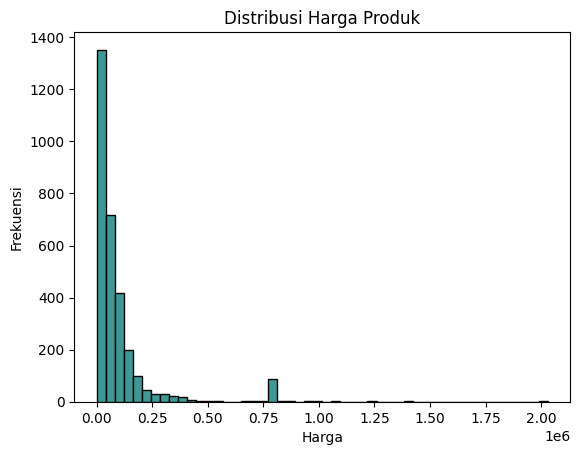

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['harga'], bins=50, color='#3E9996', edgecolor='black')
plt.title('Distribusi Harga Produk')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.show()

In [ ]:
# @title statistika deskriptif

df[['harga', 'diskon', 'rating', 'jumlah_terjual']].describe()

,harga,diskon,rating,jumlah_terjual
count,3044.0,3044.000000,2092.000000,3044.0
mean,97457.000329,0.168679,4.897323,1695.691196
std,154777.570728,0.167289,0.164938,8725.782417
min,1500.0,0.000000,1.000000,0.0
25%,28100.0,0.000000,4.900000,0.0
50%,49000.0,0.150000,4.900000,19.0
75%,99500.0,0.300000,5.000000,420.0
max,2030000.0,0.690000,5.000000,183300.0


In [ ]:
# @title produk terlaris

top_produk = df.sort_values(by='jumlah_terjual', ascending=False).head(10)
top_produk[['toko', 'nama_produk', 'harga', 'jumlah_terjual']]

,toko,nama_produk,harga,jumlah_terjual
324,Watsons,Emina Sun Battle Bright Glow Spf 35 Pa+++ 50ml,34000,183300
669,Watsons,Freshcare Press & Relax Minyak Kayu Putih 10ml,19000,164000
127,Watsons,Freshcare Press & Relax Strong 10ml,11000,145000
49,Watsons,Nuvo Family Sabun Mandi Cair Merah Pouch 800ml,25500,134800
45,Watsons,Nuvo Family Sabun Mandi Cair Mild Protect Biru...,25500,126200
332,Watsons,Cetaphil Gentle Skin Cleanser 473ml,192000,109800
1,Watsons,K Natural Body Wash Sparkling Magnolia Pouch 4...,13000,107800
726,Watsons,Emina Bright Stuff Moisturizing Cream 20ml,26500,98600
1280,Watsons,Emina Bright Stuff Niacinamide Oxy Ceramide Br...,27200,97200
0,Watsons,Giv Beauty Liquid Bodywash Purple Passion Flow...,24000,78900


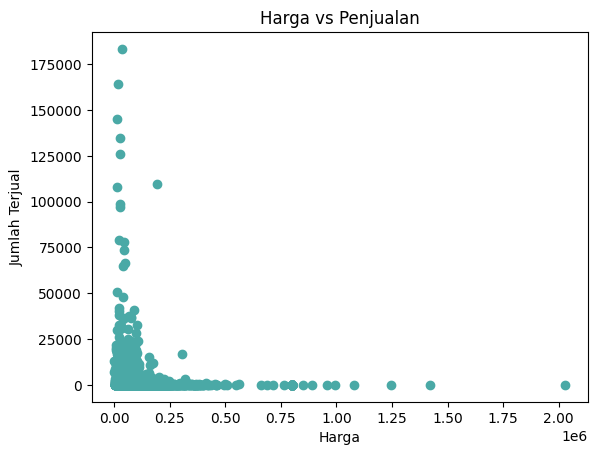

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['harga'], df['jumlah_terjual'], color='#4AA9A6')

plt.title('Harga vs Penjualan')
plt.xlabel('Harga')
plt.ylabel('Jumlah Terjual')
plt.show()

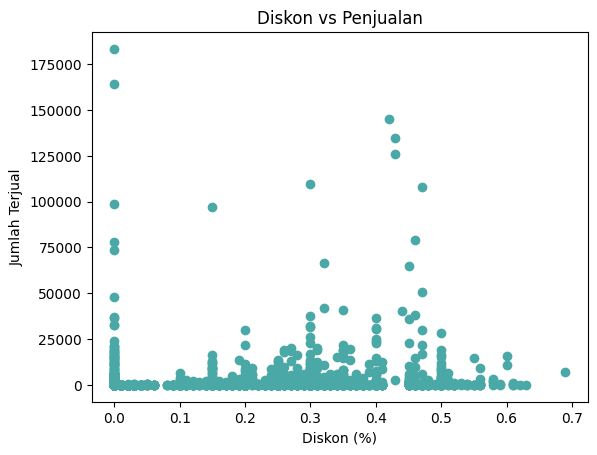

In [ ]:
# @title hubungan antara dskon dengan penjualan

plt.figure()
plt.scatter(df['diskon'], df['jumlah_terjual'], color='#4AA9A6')
plt.title('Diskon vs Penjualan')
plt.xlabel('Diskon (%)')
plt.ylabel('Jumlah Terjual')
plt.show()

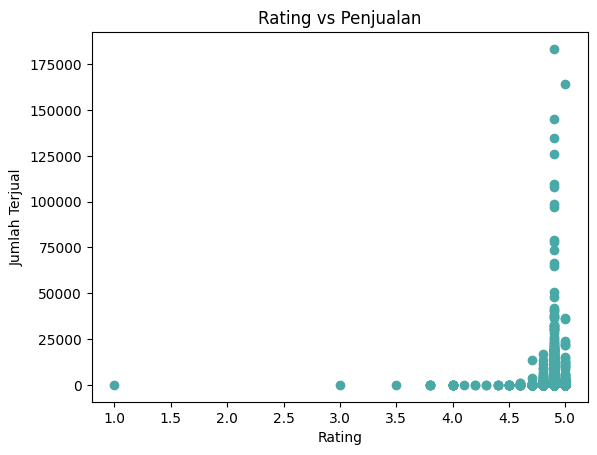

In [ ]:
# @title hubungan antara rating dengan penjualan

plt.figure()
plt.scatter(df['rating'], df['jumlah_terjual'], color='#4AA9A6')
plt.title('Rating vs Penjualan')
plt.xlabel('Rating')
plt.ylabel('Jumlah Terjual')
plt.show()

In [ ]:
# @title korelasi antar variabel

df[['harga', 'diskon', 'rating', 'jumlah_terjual']].corr()

,harga,diskon,rating,jumlah_terjual
harga,1.000000,-0.199596,0.032387,-0.062998
diskon,-0.199596,1.000000,0.015806,0.085614
rating,0.032387,0.015806,1.000000,0.014493
jumlah_terjual,-0.062998,0.085614,0.014493,1.000000


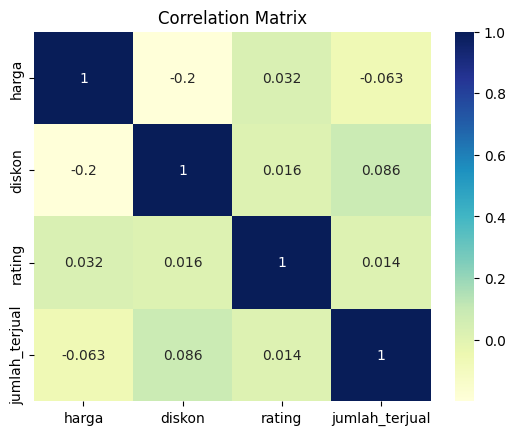

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(
    df[['harga', 'diskon', 'rating', 'jumlah_terjual']].corr(),
    annot=True,
    cmap="YlGnBu"
)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# @title pengaruh penjualan berdasarkan produk dengan review vs tanpa review

df['punya_review'] = df['jumlah_review'] > 0
df.groupby('punya_review')['jumlah_terjual'].mean()

,jumlah_terjual
punya_review,
False,2.378926
True,2508.184735


# **Comparative Analysis (Watsons vs DanDan**

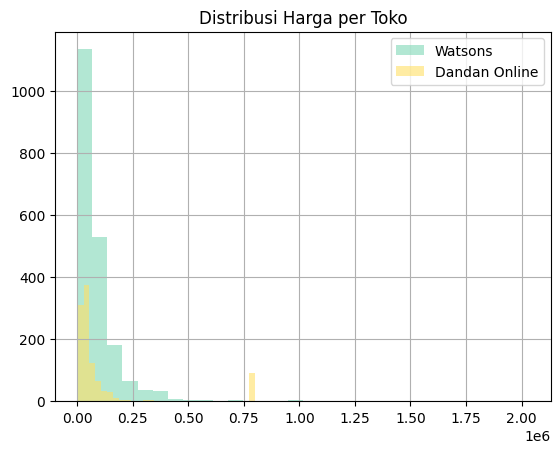

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

colors = ["#7fd8b6", "#ffe066"]  # ijo muda soft, kuning muda soft

for i, toko in enumerate(df['toko'].unique()):
    subset = df[df['toko'] == toko]
    subset['harga'].hist(
        bins=30,
        alpha=0.6,
        label=toko,
        color=colors[i % len(colors)]
    )

plt.legend()
plt.title('Distribusi Harga per Toko')
plt.show()

In [ ]:
# @title perbandingan penjualan

df.groupby('toko')['jumlah_terjual'].describe()

,count,mean,std,min,25%,50%,75%,max
toko,,,,,,,,
Dandan Online,1044.0,15.241379,61.377626,0.0,0.0,0.0,6.25,915.0
Watsons,2000.0,2572.886,10661.014217,0.0,9.0,153.5,1100.0,183300.0


In [ ]:
# @title perbandingan rata-rata diskon yang diberikan

df.groupby('toko')['diskon'].mean()

,diskon
toko,
Dandan Online,0.091006
Watsons,0.209225


In [ ]:
# @title perbandingan rata-rata rating

df.groupby('toko')['rating'].mean()

,rating
toko,
Dandan Online,4.854458
Watsons,4.907931


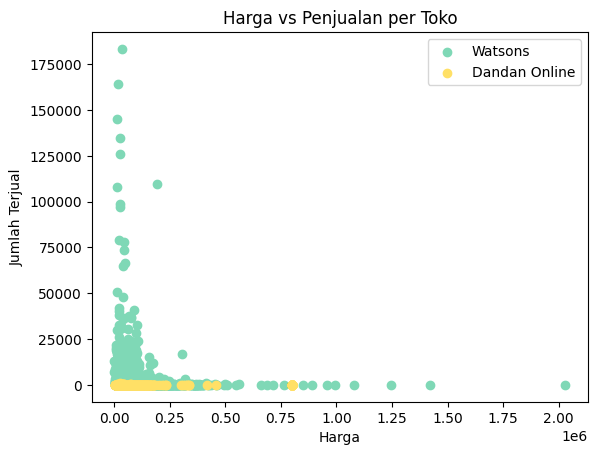

In [ ]:
plt.figure()

colors = ["#7fd8b6", "#ffe066"]

for i, toko in enumerate(df['toko'].unique()):
    subset = df[df['toko'] == toko]
    plt.scatter(
        subset['harga'],
        subset['jumlah_terjual'],
        label=toko,
        color=colors[i % len(colors)]
    )

plt.legend()
plt.title('Harga vs Penjualan per Toko')
plt.xlabel('Harga')
plt.ylabel('Jumlah Terjual')
plt.show()

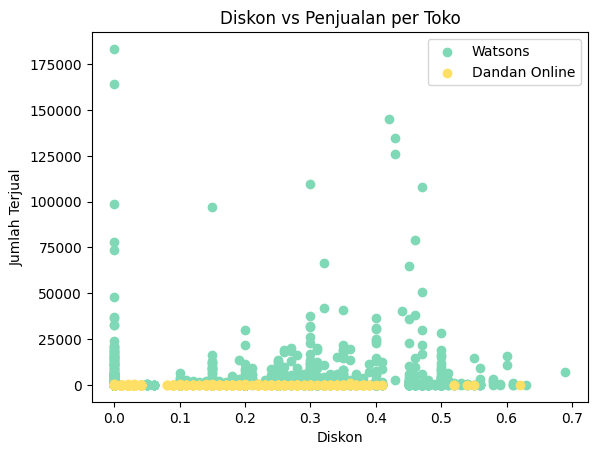

In [ ]:
plt.figure()

colors = ["#7fd8b6", "#ffe066"]

for i, toko in enumerate(df['toko'].unique()):
    subset = df[df['toko'] == toko]
    plt.scatter(
        subset['diskon'],
        subset['jumlah_terjual'],
        label=toko,
        color=colors[i % len(colors)]
    )

plt.legend()
plt.title('Diskon vs Penjualan per Toko')
plt.xlabel('Diskon')
plt.ylabel('Jumlah Terjual')
plt.show()

In [ ]:
# @title produk terlaris per toko

top_per_toko = df.sort_values(by='jumlah_terjual', ascending=False).groupby('toko').head(5)
top_per_toko[['toko', 'nama_produk', 'jumlah_terjual']]

,toko,nama_produk,jumlah_terjual
324,Watsons,Emina Sun Battle Bright Glow Spf 35 Pa+++ 50ml,183300
669,Watsons,Freshcare Press & Relax Minyak Kayu Putih 10ml,164000
127,Watsons,Freshcare Press & Relax Strong 10ml,145000
49,Watsons,Nuvo Family Sabun Mandi Cair Merah Pouch 800ml,134800
45,Watsons,Nuvo Family Sabun Mandi Cair Mild Protect Biru...,126200
2446,Dandan Online,VASELINE Repairing Jelly Aloe Vera 50gr,915
2059,Dandan Online,LA TULIPE Bedak TWC Two Function Cake Refill -...,699
2146,Dandan Online,PONDS Bright Miracle Niasorcinol Facial Foam 1...,696
2553,Dandan Online,VASELINE Repairing Jelly Original 100ml,528
2648,Dandan Online,VASELINE Healhty Bright UV Extra Brightening G...,493


# **Add-Ons**

In [ ]:
# @title hidden gems barang murah tapi laku

hidden_gems = df[
    (df['harga'] < df['harga'].median()) &
    (df['jumlah_terjual'] > df['jumlah_terjual'].quantile(0.75))
]

hidden_gems[['toko', 'nama_produk', 'harga', 'jumlah_terjual', 'rating']].head(10)

,toko,nama_produk,harga,jumlah_terjual,rating
0,Watsons,Giv Beauty Liquid Bodywash Purple Passion Flow...,24000,78900,4.9
1,Watsons,K Natural Body Wash Sparkling Magnolia Pouch 4...,13000,107800,4.9
2,Watsons,Zinc Shampoo Refreshing Cool Green Tea Pump 680ml,39900,64900,4.9
3,Watsons,Watsons Rose Scented Cream Bath Pouch 800ml,21000,1500,4.9
4,Watsons,Giv White Mulberry & Collagen Liquid Bath Soap...,24000,38200,4.9
5,Watsons,Ciptadent Maxi Jumbo Cool Mint Toothpaste 225+25g,10000,19100,4.9
6,Watsons,Nuvo Family Body Wash Fresh Protect 800g,25500,2800,4.9
7,Watsons,Watsons Green Tea Scented Cream Bath 1000ml,26500,962,4.9
8,Watsons,Vaseline Gluta-Hya Serum Lotion Overnight 200 Ml,36500,1300,4.9
23,Watsons,WATSONS Washproof Plaster 25s,11500,572,5.0


In [ ]:
# @title outlier harga mahal banget

outlier_harga = df[df['harga'] > df['harga'].quantile(0.99)]
outlier_harga[['toko', 'nama_produk', 'harga']].sort_values(by='harga', ascending=False)
#

,toko,nama_produk,harga
1707,Watsons,MARTIDERM Proteos Liposome - 30 Ampoules,2030000
1912,Watsons,Martiderm Photo-Age HA+ - 30 ampoules Silver r...,1420000
1932,Watsons,"Nuxe Super Serum [10] Yeux-Eyes, the Universal...",1245000
1255,Watsons,La Roche Posay Mela B3 Niacinamide Serum Inten...,1077000
1702,Watsons,Isdin Isdinceutics Vital Eyes 20ml,995000
949,Watsons,La Roche Posay Hyalu B5 Suractivated Serum 50m...,958000
1413,Watsons,Martiderm Expression Gel Silver 15 ml,890000
1632,Watsons,Martiderm Proteos Liposome - 10 ampoules Red 2 ml,850000


In [ ]:
# @title diskon tinggi tapi nggak laku

gagal_diskon = df[
    (df['diskon'] > df['diskon'].quantile(0.75)) &
    (df['jumlah_terjual'] < df['jumlah_terjual'].median())
]

gagal_diskon[['toko', 'nama_produk', 'diskon', 'jumlah_terjual']]

,toko,nama_produk,diskon,jumlah_terjual
11,Watsons,Watsons Avocado Conditioning Treatment Wax 500ml,0.47,12
12,Watsons,Watsons Bi-Phase Micellar Water Deep Cleanser ...,0.47,16
15,Watsons,Watsons Micellar Water Gentle for Sensitive Sk...,0.52,9
17,Watsons,Naturals by Watsons Sakura Hand Cream 30ml,0.31,0
21,Watsons,Naturals by Watsons Olive Deep Moisturizing Bo...,0.32,11
...,...,...,...,...
3467,Dandan Online,Hanasui Next Level Setting Spray 90ml - Matte ...,0.38,0
3474,Dandan Online,Hanasui Next Level Setting Spray 90ml - Glow &...,0.38,0
3517,Dandan Online,Maybelline Tattoo Brow Pencil Grey Brown 433644,0.34,0
3540,Dandan Online,Maybelline Tattoo Brow Pencil Dark Brown 433646,0.34,0
